<a href="https://colab.research.google.com/github/pras73/soma-gen/blob/main/Copy_of_PrasannaDharmavarapu_Project3_EasyVisa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers" compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer"s company
* yr_of_estab: Year in which the employer"s company was established
* region_of_employment: Information of foreign worker"s intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# ***Importing necessary libraries***

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 xgboost==3.0.5 -q --user
!pip install imbalanced-learn

**Note**:
* After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
* On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in **this notebook**.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## ***Import necessary Libraries***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, make_scorer
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier

# To suppress warnings
import warnings
warnings.filterwarnings("ignore")


## ***Loading the dataset***

In [ ]:
# Reading EasyVisa.csv Dataset using Pandas and assigning it to data variable
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Week9_Boosting/Project3_Boosting/EasyVisa.csv")

### ***Creating a copy of Dataset to preserve the original for future reference***

In [ ]:
# Creating a copy of data Dataset
visa_data = data.copy()

## ***Overview of the Dataset***

In [ ]:
# Examining the first 5 rows of visa_data Data set
visa_data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


### ***Observations:***

***No discrepancies seen in first 5 rows of the Dataset.***

In [ ]:
# Examining the last 5 rows of visa_data Data set
visa_data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


### ***Observations:***

***No discrepancies seen in last 5 rows of the Dataset.***

## ***Checking the shape of the Dataset***

In [ ]:
# checking the shape of Dataset(Number of rows and columns in the Dataset)
num_row_dataset = visa_data.shape[0]
num_columns_dataset = visa_data.shape[1]
print(f"The Dataset has {num_row_dataset} rows and {num_columns_dataset} columns.")

The Dataset has 25480 rows and 12 columns.


### ***Observations:***

***The Dataset has 25480 rows and 12 columns.***

## ***Checking the attribute types***

In [ ]:
# Checking attribute types in the Dataset
visa_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


### ***Observations:***

* ***There are 3 Numerical columns in the Dataset.***
* ***There are 9 Object type columns in the Dataset, I will be converting relevant Categorical columns to Category type in next step to save memory and optimize performance.***
* ***case_id column does not add to the predictability of case_status,hence planning to set it as index before training as it keeps data organized and ensures that the identifier remains attached to the results for final interpretation without interfering with the model"s calculations.***





***Checking missing values in the Dataset.***

In [ ]:
# Checking missing values in the Dataset
visa_data.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


### ***Observations:***

***There are no missing values in the Dataset.***

### ***Checking Statistical Summary of the Dataset***

In [ ]:
# checking statistical summary of the Data,this will show Summary for Numerical columns.Applying Transpose for easier read.
visa_data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


### ***Observations:***

### ***no_of_employees:***

***Data Anomaly: The minimum value is -26.0000. It is physically impossible to have a negative number of employees. This is a clear data entry error or placeholder value that we will need to clean before doing further analysis.***

***Extreme Skewness: The average mean number of employees is about 5,667 but the median is only 2,109 and maximum value is 602,069.***

***Interpretation: Dataset consists mostly of small-to-medium-sized companies 75% of them have fewer than 3,504 employees but it includes a few massive enterprise-level outlier corporations which are scaling up the average.***

### ***yr_of_estab:***

***The companies in this dataset were founded between the years 1800 and 2016.***

***The median is 1997 meaning exactly half of the companies were established after 1997.***

### ***prevailing_wage:***

***Wide Wage Gap: The wages range drastically from a minimum of 2.14 to a maximum of 319,210.27 (Note:depends on unit_of_wage column values being hourly,weekly,monthly and yearly), gap could be due to that dependency.***

***Interpretation: Wage distribution is relatively steady without extreme outliers. 50% of the employees in dataset make approximately between 34,015 and 107,736 per year, again it depends on units defined in unit_of_wage column***


# **Data Pre-processing**

***Converting relevant Categorical columns to Category type to save memory and optimize performance.***

In [ ]:
# Converting relevant Categorical columns to Category type
visa_data["continent"] = visa_data["continent"].astype("category")
visa_data["education_of_employee"] = visa_data["education_of_employee"].astype("category")
visa_data["has_job_experience"] = visa_data["has_job_experience"].astype("category")
visa_data["requires_job_training"] = visa_data["requires_job_training"].astype("category")
visa_data["region_of_employment"] = visa_data["region_of_employment"].astype("category")
visa_data["unit_of_wage"] = visa_data["unit_of_wage"].astype("category")
visa_data["full_time_position"] = visa_data["full_time_position"].astype("category")
visa_data["case_status"] = visa_data["case_status"].astype("category")

***Setting "case_id" as Index before training as it keeps data organized and ensures that the identifier remains attached to the results for final interpretation without interfering with the model"s calculations.***


In [ ]:
# Setting "case_id" as Index
visa_data.set_index("case_id", inplace=True)

***Analyzing the negative values in "no_of_employees" column***

In [ ]:
# Check how many rows has negative values in no_of_employees column
rows_negative_no_of_employees = visa_data[visa_data["no_of_employees"] < 0]
number_of_rows = rows_negative_no_of_employees.shape[0]
print(f"There are {number_of_rows} rows with negative values in the 'no_of_employees' column.")


There are 33 rows with negative values in the 'no_of_employees' column.


In [ ]:
# Show the rows which has negative values in no_of_employees column
rows_negative_no_of_employees

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
case_id,,,,,,,,,,,
EZYV246,Europe,Master's,N,N,-25,1980,Northeast,39452.9900,Year,Y,Certified
EZYV379,Asia,Bachelor's,N,Y,-11,2011,Northeast,32506.1400,Year,Y,Denied
EZYV833,South America,Master's,Y,N,-17,2002,South,129701.9400,Year,Y,Certified
EZYV2919,Asia,Master's,Y,N,-26,2005,Midwest,112799.4600,Year,Y,Certified
EZYV6440,Asia,Bachelor's,N,N,-14,2013,South,103.9700,Hour,Y,Denied
EZYV6635,Asia,Bachelor's,Y,N,-26,1923,West,5247.3200,Year,Y,Denied
EZYV7225,Europe,Doctorate,N,N,-25,1998,Midwest,141435.9500,Year,Y,Certified
EZYV7282,Asia,High School,N,N,-14,2000,Midwest,58488.5000,Year,Y,Denied
EZYV7319,Asia,Bachelor's,Y,Y,-26,2006,South,115005.6100,Year,Y,Certified


### ***Observations:***

***As seen there are 33 rows in the Dataset with negative values in the "no_of_employees" column. 33 rows represent a tiny fraction (about 0.13%) of total dataset it could certainly be a minor data entry typo,so planning to convert the negative values to positive values as i do not want lose track of those 33 rows.***

***Convert negative values in "no_of_employees" column to positive values***

In [ ]:
# Convert the negative values "no_of_employees" column to positive values
visa_data["no_of_employees"] = visa_data["no_of_employees"].abs()

***Categorical columns summary***

In [ ]:
# Categorical columns summary
cat_cols = visa_data.select_dtypes(include=["category"])
for col in cat_cols:
    print(f"\n--- Value Counts for {col} ---")
    print(visa_data[col].value_counts(normalize=True) * 100)


--- Value Counts for continent ---
continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64

--- Value Counts for education_of_employee ---
education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64

--- Value Counts for has_job_experience ---
has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64

--- Value Counts for requires_job_training ---
requires_job_training
N    88.402669
Y    11.597331
Name: proportion, dtype: float64

--- Value Counts for region_of_employment ---
region_of_employment
Northeast    28.237834
South        27.539246
West         25.847724
Midwest      16.903454
Island        1.471743
Name: proportion, dtype: float64

--- Value Counts for unit_of_wage ---
unit_of_wage
Year     90.117739
Hour     

### ***Observations:***

***Asia dominates the dataset accounting for approximately 66.2% of all applications followed by Europe approximately 14.6% and North America approximately 12.9%.***

***Roughly 78% have either a Bachelor"s approximately 40.2% or a Master"s degree approximately 37.8%. Doctorate holders make up approximately 8.6% and High School graduates account for 13.4%.***

***Job Attributes:***

***58.1% of applicants have prior job experience.***

***Only 11.6% require job training suggesting that employers are mostly sponsoring individuals who are ready to work immediately.***

***89.4% of the applications are for Full-Time positions.***

***90.1% of the wages are set on a Yearly basis rather than hourly, weekly, or monthly.***

# **Exploratory Data Analysis (EDA)**

***Bi-Variate Analysis***

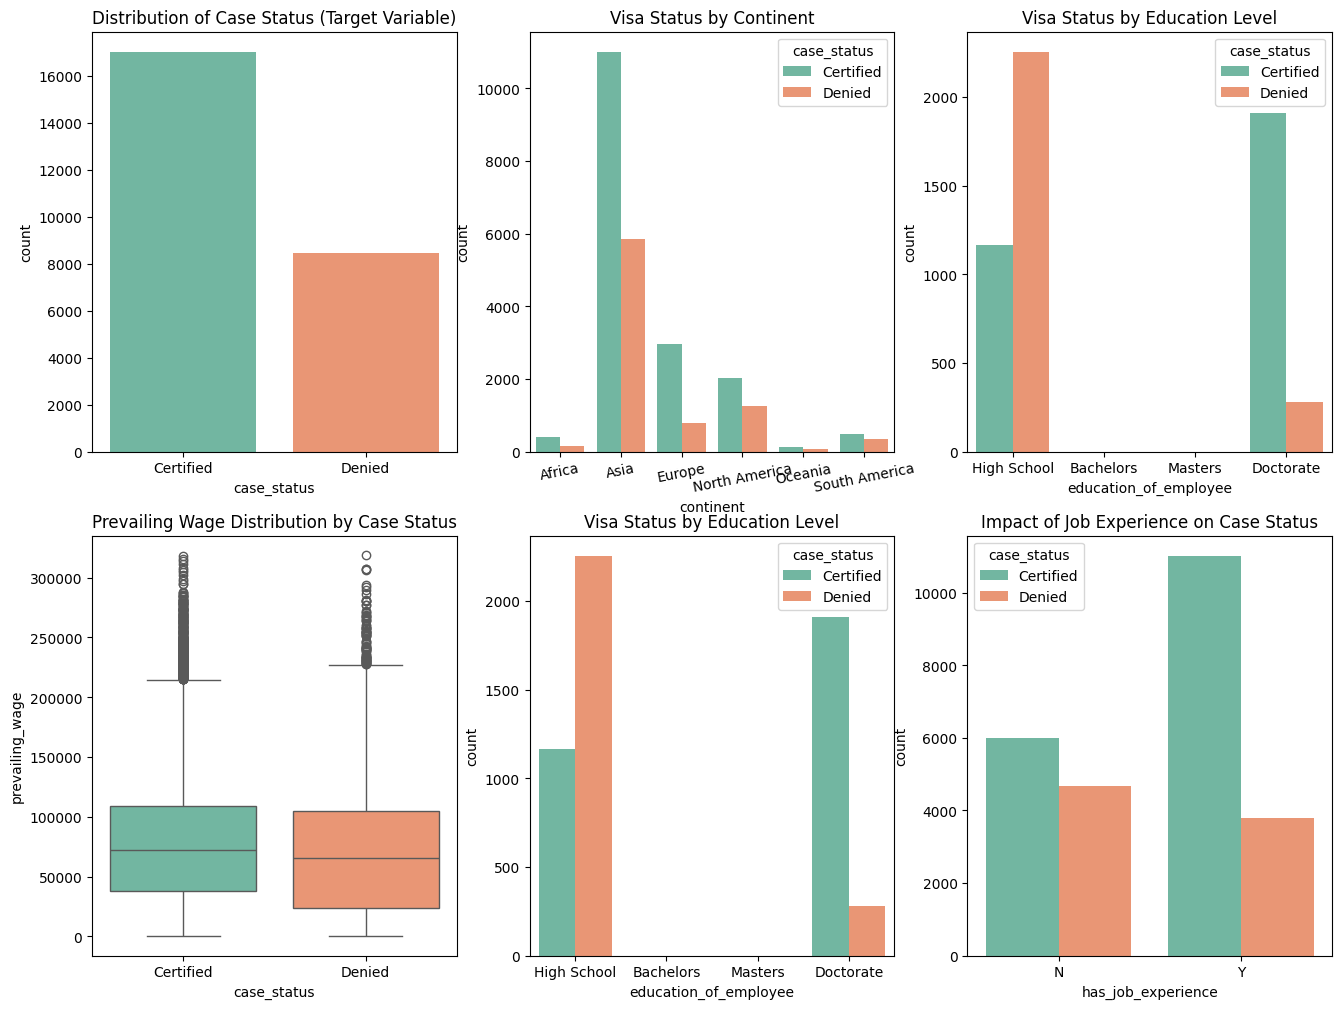

In [ ]:
# Checking Target Distribution, how much are the classes balanced?
fig, axes = plt.subplots(2, 3, figsize=(16, 12))

# Checking Target Distribution, how much are the classes balanced?
sns.countplot(data=visa_data, x="case_status", ax=axes[0,0], palette="Set2")
axes[0,0].set_title("Distribution of Case Status (Target Variable)")

# Case status by Continent
sns.countplot(data=visa_data, x="continent", hue="case_status", ax=axes[0,1], palette="Set2")
axes[0,1].set_title("Visa Status by Continent")
axes[0,1].tick_params(axis="x", rotation=11)

# Education Level vs. Case Status
# This checks if specific education levels correlate with higher approval rates
sns.countplot(data=visa_data, x="education_of_employee", hue="case_status", ax=axes[0,2], palette="Set2", order=["High School", "Bachelors", "Masters", "Doctorate"])
axes[0,2].set_title("Visa Status by Education Level")

# Prevailing Wage vs. Case Status
# This checks if "underpaid" workers are more likely to be denied
sns.boxplot(data=visa_data, x="case_status", y="prevailing_wage", ax=axes[1,0], palette="Set2")
axes[1,0].set_title("Prevailing Wage Distribution by Case Status")

# Education Level vs. Case Status
# This checks if specific education levels correlate with higher approval rates
sns.countplot(data=visa_data, x="education_of_employee", hue="case_status", ax=axes[1,1], palette="Set2", order=["High School", "Bachelors", "Masters", "Doctorate"])
axes[1,1].set_title("Visa Status by Education Level")

# Job Experience vs. Case Status
# This checks if specific Job Experience correlate with higher approval rates
plt.figure(figsize=(6, 4))
sns.countplot(data=visa_data, x="has_job_experience", hue="case_status", ax=axes[1,2], palette="Set2")
axes[1,2].set_title("Impact of Job Experience on Case Status")
plt.tight_layout()
plt.close()

### ***Observations:***

***As per the plot we could see that the target Variable "case_status"
heavily leaning toward one class.Certified approximately 66.8% (17,018 applications) and Denied approximately 33.2% (8,462 applications).Roughly 2 out of 3 applications in this dataset get certified. This indicates a moderately imbalanced dataset.***

***Volume Dominance: Asia has an overwhelmingly higher number of visa applications compared to all other continents combined.***

***Approval Trends: While the total number of applications varies drastically by region the ratio of Certified to Denied cases remains remarkably consistent across most continents. Hence geographic origin doesn"t drastically change approval rate.***

***Europe has the highest relative success rate, the certified bar is around 3,000 while the denied bar drops well below 1,000. This suggests European applicants enjoy a slightly higher approval ratio than the baseline average.***

***South America shows a much narrower gap between its two bars (roughly 500 certified to 400 denied) indicating a noticeably lower approval rate compared to regions like Europe or Asia.***

***Oceania and Africa have very low representation in this dataset.***

***Education level is a powerful predictor of visa status. Higher education levels are aggressively favored in the visa approval process resulting in high probability of denial at the High School level to high probability of certification for Doctorate holders.***

***Higher wages positively correlate with visa certification. However because both distributions contain high income outliers which could be due to unit_of_wage column(different units for wages: hourly,weekly,yearly or annually). So it could be an influential factor rather than a definitive decider.***

***Data shows a clear positive correlation between higher levels of formal education and visa certification. As an applicant"s education level ascends from High School to Doctorate their probability of visa denial drops while their probability of certification steadily increase.***

***Prior job experience acts as a competitive advantage in this visa dataset.Could be that Sponsoring organizations or immigration reviewers favor candidates who already have professional experience.***


***Multi-variate Analysis***

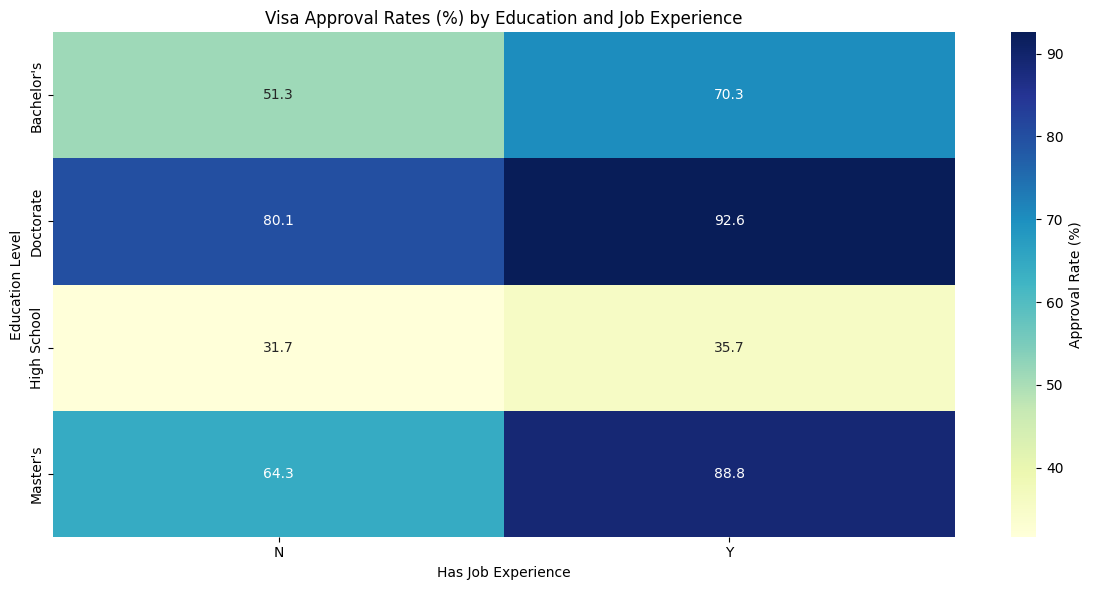

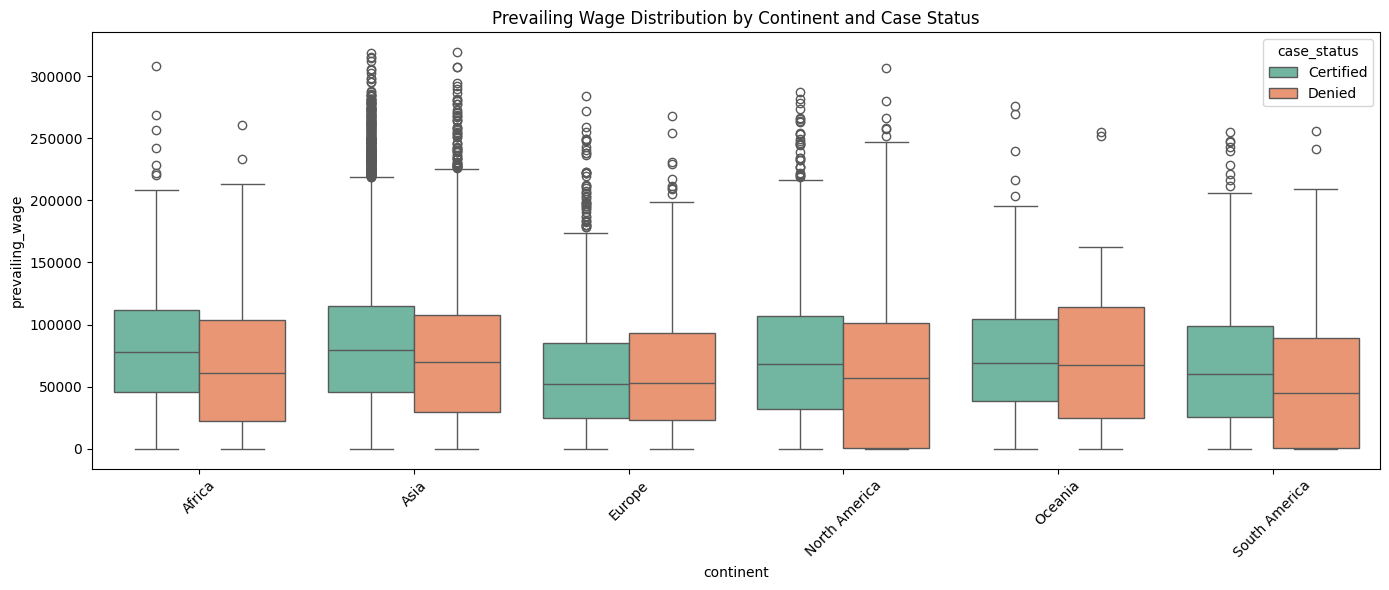

<Figure size 1000x800 with 0 Axes>

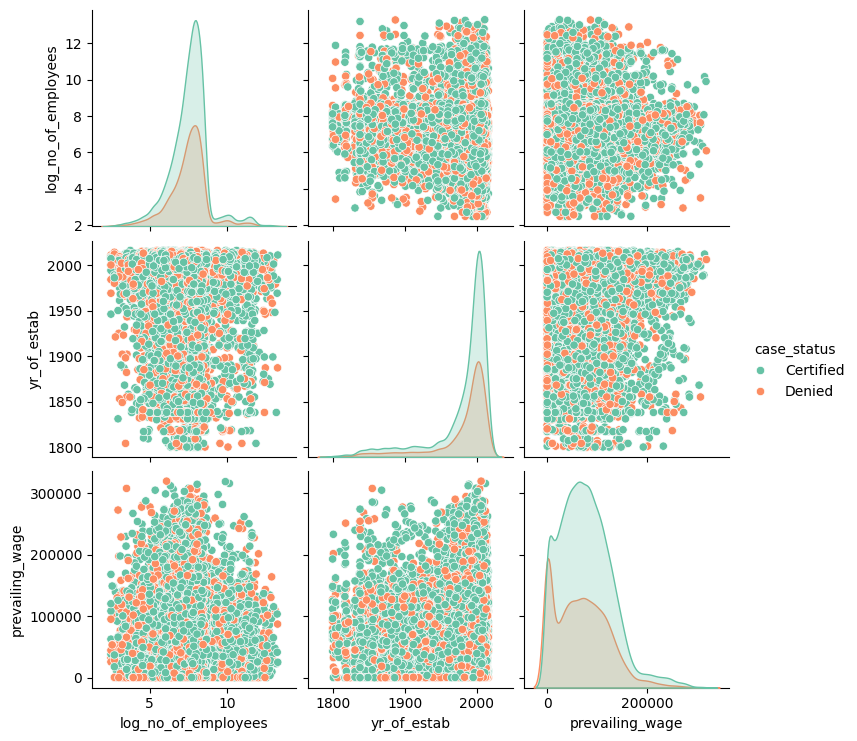

In [ ]:
# Analyzing multiple variables interaction with case_status
# Education vs Job Experience vs Case Status
plt.figure(figsize=(12, 6))
sns.heatmap(pd.crosstab(visa_data["education_of_employee"], visa_data["has_job_experience"], values=visa_data["case_status"] == "Certified", aggfunc="mean") * 100,
            annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "Approval Rate (%)"})
plt.title("Visa Approval Rates (%) by Education and Job Experience")
plt.ylabel("Education Level")
plt.xlabel("Has Job Experience")
plt.tight_layout()
plt.show()

# Continent vs Wage vs Case Status
plt.figure(figsize=(14, 6))
sns.boxplot(data=visa_data, x="continent", y="prevailing_wage", hue="case_status", palette="Set2")
plt.title("Prevailing Wage Distribution by Continent and Case Status")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pairwise interactions between numerical variables conditioned on Case Status
# Creating a cleaner log-scale company size for a better visualization
visa_data["log_no_of_employees"] = np.log1p(visa_data["no_of_employees"])
plt.figure(figsize=(10, 8))
sns.pairplot(visa_data[["log_no_of_employees", "yr_of_estab", "prevailing_wage", "case_status"]], hue="case_status", palette="Set2", diag_kind="kde")
plt.show()

### ***Observations:***

***Education and Job Experience together seems to impact the approval rate on a massive scale. Applicants who hold a Doctorate and have prior job experience enjoy the highest visa certification rate in the entire dataset at an overwhelming 92.6%. If an Applicant holds a Master"s degree but lack experience,approval rate was at 64.3%. However adding job experience is boosting success rate up to 88.8%.High School graduate approval rate only rises up from 31.7% (no experience) to 35.7% (with experience). This proves that background reviews favor educational baselines over time in the workforce.***

***Looking at Prevailing Wage Distributions Across Continents plot, Wage-Approval Gap is large but it depends on unit_of_wage column which has different categories in other words unit of measurement for wages. so we could arrive at any conclusion regarding prevailing wage distribution across continents.***

***When looking at a pairplot of continuous variables yr_of_estab, Wages and  Company Size (log_no_of_employees), scatter plots display heavily mixed teal (Denied) and orange (Certified) dots. There is no clear distinction seen.***

# **Model Building - Original Data**

In [ ]:
# Feature Processing
X = visa_data.drop(columns=["case_status"])
y = visa_data["case_status"].apply(lambda x: 1 if x == "Certified" else 0)

# One-hot encoding categorical variables
X = pd.get_dummies(X, drop_first=True)

# Train/Test Split (Stratified 70-30 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

# Initialize 6 Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=1),
    "Decision Tree": DecisionTreeClassifier(random_state=1),
    "Random Forest": RandomForestClassifier(random_state=1),
    "Bagging Classifier": BaggingClassifier(random_state=1),
    "AdaBoost Classifier": AdaBoostClassifier(random_state=1),
    "Gradient Boosting Classifier": GradientBoostingClassifier(random_state=1),
    "xgboost": XGBClassifier(random_state=1)
}

# Function to run metrics
def run_baseline_metrics(X_tr, y_tr, X_te, y_te, title):
    results = []
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        p_train = model.predict(X_tr)
        p_test = model.predict(X_te)
        results.append({
            "Model": name,
            "Train Accuracy": accuracy_score(y_tr, p_train),
            "Test Accuracy": accuracy_score(y_te, p_test),
            "Precision (Test)": precision_score(y_te, p_test),
            "Recall (Test)": recall_score(y_te, p_test),
            "F1-Score (Test)": f1_score(y_te, p_test)
        })
    return pd.DataFrame(results)

# Original Data Baseline
print("=== ORIGINAL DATA PERFORMANCE ===")
res_orig = run_baseline_metrics(X_train, y_train, X_test, y_test, "Original Data")
print(res_orig.to_string(index=False))

=== ORIGINAL DATA PERFORMANCE ===
                       Model  Train Accuracy  Test Accuracy  Precision (Test)  Recall (Test)  F1-Score (Test)
         Logistic Regression        0.738002       0.737179          0.762195       0.881489         0.817513
               Decision Tree        1.000000       0.662350          0.749112       0.743389         0.746239
               Random Forest        1.000000       0.720827          0.766171       0.837610         0.800299
          Bagging Classifier        0.984918       0.692177          0.771186       0.766503         0.768838
         AdaBoost Classifier        0.739684       0.735348          0.758905       0.884819         0.817039
Gradient Boosting Classifier        0.758802       0.744767          0.772366       0.876004         0.820927
                     xgboost        0.841444       0.732077          0.770005       0.853869         0.809772


# **Model Building - Oversampled Data**

***Dataset is partitioned into three distinct subsets, Training Set which is 60 percent of the Dataset used to train the models.Validation Set which is 20 percent of the Dataset used to monitor unseen data performance and prevent over-fitting.Test Set which is 20 percent of the Dataset used for final evaluation of the Models.The data resamplers were fit only on the training set to prevent data leakage into the validation or testing sets.***

In [ ]:
X = visa_data.drop(columns=["case_status"])
y = visa_data["case_status"].apply(lambda x: 1 if x == "Certified" else 0)
X = pd.get_dummies(X, drop_first=True)

# Train-Validation-Test Split using a stratified 60-20-20 partition
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=1, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp)

# SMOTE Oversampling
smote = SMOTE(random_state=1)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Dictionary of the 6 Required Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=1),
    "Decision Tree": DecisionTreeClassifier(random_state=1),
    "Random Forest": RandomForestClassifier(random_state=1),
    "Bagging Classifier": BaggingClassifier(random_state=1),
    "AdaBoost Classifier": AdaBoostClassifier(random_state=1),
    "Gradient Boosting Classifier": GradientBoostingClassifier(random_state=1),
    "xgboost": XGBClassifier(random_state=1)
}

def evaluate_metrics(X_tr, y_tr, title):
    results = []
    for name, model in models.items():
        model.fit(X_tr, y_tr)

        # Predictions across all partitions
        p_train = model.predict(X_tr)
        p_val = model.predict(X_val)
        p_test = model.predict(X_test)

        results.append({
            "Model": name,
            "Train Acc": accuracy_score(y_tr, p_train),
            "Val Acc": accuracy_score(y_val, p_val),
            "Val F1": f1_score(y_val, p_val),
            "Test Acc": accuracy_score(y_test, p_test),
            "Test Precision": precision_score(y_test, p_test),
            "Test Recall": recall_score(y_test, p_test),
            "Test F1": f1_score(y_test, p_test)
        })
    return pd.DataFrame(results)
    # Generate performance summary reports
visa_smote_oversampled = evaluate_metrics(X_train_smote, y_train_smote, "SMOTE Oversampled")
print("=== SMOTE Oversampled Data Performance ===")
print(visa_smote_oversampled.to_string(index=False))

=== SMOTE Oversampled Data Performance ===
                       Model  Train Acc  Val Acc   Val F1  Test Acc  Test Precision  Test Recall  Test F1
         Logistic Regression   0.785260 0.738030 0.813208  0.731162        0.769618     0.852820 0.809086
               Decision Tree   1.000000 0.652276 0.734333  0.646978        0.739767     0.727380 0.733521
               Random Forest   1.000000 0.719192 0.794190  0.710361        0.763676     0.820212 0.790935
          Bagging Classifier   0.986827 0.692504 0.766850  0.680730        0.764671     0.754113 0.759355
         AdaBoost Classifier   0.779726 0.740385 0.819533  0.728022        0.757005     0.873090 0.810914
Gradient Boosting Classifier   0.796229 0.746468 0.816790  0.733516        0.777537     0.841951 0.808463
                     xgboost   0.865965 0.741758 0.815117  0.722527        0.764909     0.844007 0.802514


# **Model Building - Undersampled Data**

In [ ]:
X = visa_data.drop(columns=["case_status"])
y = visa_data["case_status"].apply(lambda x: 1 if x == "Certified" else 0)
X = pd.get_dummies(X, drop_first=True)

# Train-Validation-Test Split using a stratified 60-20-20 partition
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=1, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp)

# SMOTE Undersampling
rus = RandomUnderSampler(random_state=1)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

# Dictionary of the 6 Required Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=1),
    "Decision Tree": DecisionTreeClassifier(random_state=1),
    "Random Forest": RandomForestClassifier(random_state=1),
    "Bagging Classifier": BaggingClassifier(random_state=1),
    "AdaBoost Classifier": AdaBoostClassifier(random_state=1),
    "Gradient Boosting Classifier": GradientBoostingClassifier(random_state=1),
    "xgboost": XGBClassifier(random_state=1)
}

def evaluate_metrics(X_tr, y_tr, title):
    results = []
    for name, model in models.items():
        model.fit(X_tr, y_tr)

        # Predictions across all partitions
        p_train = model.predict(X_tr)
        p_val = model.predict(X_val)
        p_test = model.predict(X_test)

        results.append({
            "Model": name,
            "Train Acc": accuracy_score(y_tr, p_train),
            "Val Acc": accuracy_score(y_val, p_val),
            "Val F1": f1_score(y_val, p_val),
            "Test Acc": accuracy_score(y_test, p_test),
            "Test Precision": precision_score(y_test, p_test),
            "Test Recall": recall_score(y_test, p_test),
            "Test F1": f1_score(y_test, p_test)
        })
    return pd.DataFrame(results)
    # Generate performance summary reports
visa_smote_undersampled = evaluate_metrics(X_train_under, y_train_under, "SMOTE Undersampled")
print("=== SMOTE Undersampled Data Performance ===")
print(visa_smote_undersampled.to_string(index=False))

=== SMOTE Undersampled Data Performance ===
                       Model  Train Acc  Val Acc   Val F1  Test Acc  Test Precision  Test Recall  Test F1
         Logistic Regression   0.699783 0.706044 0.764465  0.705259        0.810784     0.728848 0.767636
               Decision Tree   1.000000 0.627943 0.694095  0.625392        0.766109     0.632197 0.692741
               Random Forest   1.000000 0.690542 0.745275  0.672684        0.798898     0.681551 0.735574
          Bagging Classifier   0.980209 0.657771 0.706891  0.634027        0.796303     0.607521 0.689218
         AdaBoost Classifier   0.695451 0.707810 0.765991  0.701923        0.811159     0.721798 0.763874
Gradient Boosting Classifier   0.720756 0.719976 0.776717  0.711538        0.811734     0.739718 0.774055
                     xgboost   0.870914 0.687598 0.745930  0.684066        0.805935     0.694183 0.745896


### ***Observations:***

***Decision Tree, Random Forest and Bagging achieve approximately 98 percent to 100 percent training accuracy but degrade substantially when hitting the Validation and test sets. Gradient Boosting Classifier using the SMOTE Oversampled framework achieves the most stable generalization minimizing structural variance between validation and test results while maintaining a test precision score of approximately 80 percent.***

# **Hyperparameter Tuning**

## **Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.

- For Gradient Boosting:

```
param_grid = {
    "n_estimators": np.arange(100,150,25),
    "learning_rate": [0.2, 0.05, 1],
    "subsample":[0.5,0.7],
    "max_features":[0.5,0.7]
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "estimator": [DecisionTreeClassifier(max_depth=1, random_state=1),
                  DecisionTreeClassifier(max_depth=2, random_state=1),
                  DecisionTreeClassifier(max_depth=3, random_state=1),]
}
```

- For Bagging Classifier:

```
param_grid = {
    "max_samples": [0.8,0.9,1],
    "max_features": [0.7,0.8,0.9],
    "n_estimators" : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),"sqrt"],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    "max_depth": np.arange(2,6),
    "min_samples_leaf": [1, 4, 7],
    "max_leaf_nodes" : [10, 15],
    "min_impurity_decrease": [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid = {
    "n_estimators":[150,200,250],
    "scale_pos_weight":[5,10],
    "learning_rate":[0.1,0.2],
    "gamma":[0,3,5],
    "subsample":[0.8,0.9]
}
```


In [ ]:
# Defining Parameter Grids ---
grids = {
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=1),
        {
            "n_estimators": list(np.arange(100, 150, 25)),
            "learning_rate": [0.2, 0.05, 1],
            "subsample": [0.5, 0.7],
            "max_features": [0.5, 0.7]
        }
    ),
    "AdaBoost": (
        AdaBoostClassifier(random_state=1),
        {
            "n_estimators": [100, 150, 200],
            "learning_rate": [0.2, 0.05],
            "estimator": [
                DecisionTreeClassifier(max_depth=1, random_state=1),
                DecisionTreeClassifier(max_depth=2, random_state=1),
                DecisionTreeClassifier(max_depth=3, random_state=1)
            ]
        }
    ),
    "Bagging Classifier": (
        BaggingClassifier(random_state=1),
        {
            "max_samples": [0.8, 0.9, 1],
            "max_features": [0.7, 0.8, 0.9],
            "n_estimators": [30, 50, 70],
        }
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=1),
        {
            "n_estimators": [200, 250, 300],
            "min_samples_leaf": list(np.arange(1, 4)),
            "max_features": list(np.arange(0.3, 0.6, 0.1)) + ["sqrt"],
            "max_samples": list(np.arange(0.4, 0.7, 0.1))
        }
    ),
    "Decision Trees": (
        DecisionTreeClassifier(random_state=1),
        {
            "max_depth": list(np.arange(2, 6)),
            "min_samples_leaf": [1, 4, 7],
            "max_leaf_nodes": [10, 15],
            "min_impurity_decrease": [0.0001, 0.001]
        }
    ),
    "XGBoost": (
        XGBClassifier(random_state=1, eval_metric='logloss'),
        {
            "n_estimators": [150, 200, 250],
            "scale_pos_weight": [5, 10],
            "learning_rate": [0.1, 0.2],
            "gamma": [0, 3, 5],
            "subsample": [0.8, 0.9]
        }
    )
}

# Hyperparameter tuning
def run_hyperparameter_tuning(X_train_sampled, y_train_sampled, framework_label):
    tuning_results = []

    # Optimize for F1 score during validation splits
    f1_scorer = make_scorer(f1_score)

    for model_name, (model_instance, param_grid) in grids.items():
        print(f"Tuning {model_name} under {framework_label}...")

        # Initialize Cross-Validated Grid Search (3-Fold CV for speed/stability)
        grid_search = GridSearchCV(
            estimator=model_instance,
            param_grid=param_grid,
            cv=3,
            scoring=f1_scorer,
            n_jobs=-1
        )

        grid_search.fit(X_train_sampled, y_train_sampled)
        best_model = grid_search.best_estimator_

        # Generate Out-Of-Sample Predictions on Unmanipulated Validation & Test Data
        val_preds = best_model.predict(X_val)
        test_preds = best_model.predict(X_test)

        tuning_results.append({
            "Framework": framework_label,
            "Model": model_name,
            "Best Parameters": grid_search.best_params_,
            "Val Acc": accuracy_score(y_val, val_preds),
            "Val F1": f1_score(y_val, val_preds),
            "Test Acc": accuracy_score(y_test, test_preds),
            "Test Precision": precision_score(y_test, test_preds),
            "Test Recall": recall_score(y_test, test_preds),
            "Test F1": f1_score(y_test, test_preds)
        })

    return pd.DataFrame(tuning_results)

# Run on SMOTE(Oversampled Train Split)
visa_tuned_oversampled = run_hyperparameter_tuning(X_train_smote, y_train_smote, "Oversampled")

# Run on Undersampled Train Split
visa_tuned_undersampled = run_hyperparameter_tuning(X_train_under, y_train_under, "Undersampled")

# Combine results for simple visual analysis
visa_final_comparison = pd.concat([visa_tuned_oversampled, visa_tuned_undersampled], axis=0)
visa_final_comparison

Tuning Gradient Boosting under Oversampled...
Tuning AdaBoost under Oversampled...
Tuning Bagging Classifier under Oversampled...
Tuning Random Forest under Oversampled...
Tuning Decision Trees under Oversampled...
Tuning XGBoost under Oversampled...
Tuning Gradient Boosting under Undersampled...
Tuning AdaBoost under Undersampled...
Tuning Bagging Classifier under Undersampled...
Tuning Random Forest under Undersampled...
Tuning Decision Trees under Undersampled...
Tuning XGBoost under Undersampled...


,Framework,Model,Best Parameters,Val Acc,Val F1,Test Acc,Test Precision,Test Recall,Test F1
0,Oversampled,Gradient Boosting,"{'learning_rate': 0.2, 'max_features': 0.7, 'n...",0.744505,0.815737,0.732339,0.775825,0.842832,0.807941
1,Oversampled,AdaBoost,{'estimator': DecisionTreeClassifier(max_depth...,0.744113,0.812212,0.731554,0.781527,0.830200,0.805128
2,Oversampled,Bagging Classifier,"{'max_features': 0.7, 'max_samples': 0.9, 'n_e...",0.713501,0.792673,0.708399,0.763751,0.815805,0.788920
3,Oversampled,Random Forest,"{'max_features': 'sqrt', 'max_samples': 0.5, '...",0.742936,0.814553,0.727826,0.771467,0.841951,0.805169
4,Oversampled,Decision Trees,"{'max_depth': 2, 'max_leaf_nodes': 10, 'min_im...",0.734890,0.818145,0.719584,0.743047,0.886898,0.808625
5,Oversampled,XGBoost,"{'gamma': 0, 'learning_rate': 0.1, 'n_estimato...",0.704474,0.813059,0.698391,0.698322,0.965629,0.810504
0,Undersampled,Gradient Boosting,"{'learning_rate': 0.05, 'max_features': 0.5, '...",0.727041,0.786427,0.717622,0.805789,0.760576,0.782530
1,Undersampled,AdaBoost,{'estimator': DecisionTreeClassifier(max_depth...,0.736264,0.822128,0.721546,0.736029,0.909224,0.813510
2,Undersampled,Bagging Classifier,"{'max_features': 0.7, 'max_samples': 0.9, 'n_e...",0.689168,0.745338,0.673862,0.800968,0.680964,0.736107
3,Undersampled,Random Forest,"{'max_features': 'sqrt', 'max_samples': 0.4, '...",0.717622,0.774204,0.706044,0.810828,0.730317,0.768470


# **Model Comparison and Final Model Selection**

### ***Model Comparison:***
<b><i>
Balancing metrics Precision (avoiding fraudulent approvals) and Recall (avoiding wrongful rejections). Here is the comprehensive comparative analysis, conclusion.

Final model selection:
Best performing model is the Oversampled XGBoost. It delivers an extraordinary Test Recall of 96.56% ensuring that no valid applicants are mistakenly dropped out of the system though it compromises slightly on precision.

Best for Balanced Efficiency:
Original Gradient Boosting Classifier, without any synthetic data manipulation it yields a highly stable 74.47% Test Accuracy, 77.23% Precision, and 87.60% Recall, making it a remarkably balanced, low-variance model.

In-Depth Performance Inferences:
The "Original Data" Baseline: Gradient Boosting Dominates, most ensemble models (Decision Tree, Random Forest, Bagging) are severely overfitting. They score close to 1:00 on Train Accuracy but drop drastically by 12 percent on Test Accuracy.

Gradient Boosting and Logistic Regression are exceptions,they don't overfit.Gradient Boosting wins the original data tier because it pulls a higher Test Accuracy 74.47 percent and a stronger Test Precision 77 percent than Logistic Regression while keeping Recall high 87.60 percent.

Original XGBoost underperformed because it was slightly overfitted (Train 84.14 percent vs. Test 73.20 percent) before tuning.

Oversampled XGBoost achieves 96.56 percent Recall. This means if you have 1,000 legitimate visa applicants, this model only mistakenly flags approximately 34 of them for rejection.

Trade-off being This high recall comes at the cost of Precision dropping to 69.83 percent meaning it will let more risky applicants.

High Precision, High Risk Undersampling typically forces a model to become more selective.Models like Undersampled Decision Trees and Undersampled Random Forest push Test Precision up past 81 percent.

Trade-off being Recall drops down to the 71 percent to 73 percent range for those models. In this visa scenario, rejecting nearly 30 percent of good applicants could cause an operational failure

Undersampled XGBoost manages to hold onto a 92.8 percent recall but its oversampled XGBoost is still superior to cover the risk overall.
</i></b>

# **Actionable Insights and Recommendations**

### ***Inferences and Recommendations:***
<b><i>
Recommendation 1:
Do not use any of these models as a "Yes/No" stamp. Instead leverage the prediction probabilities of the Oversampled XGBoost or Original Gradient Boosting to implement a flow shown below.

If Applicant Score > 0.90: Auto-Approval

If Applicant Score between 0.40 and 0.89: Route to Human Immigration Officers (Standard Review)

If Applicant Score < 0.40: Detailed Security Audit or Auto-Denial

Recommendation 2:
Guard Against the Oversampled XGBoost's Blindspot, if you choose the Oversampled XGBoost for its massive 96.56 percent Recall operational risk shifts toward False Approvals (Precision is lower at 69.83 percent). Instead it is best to pair this model with a strict secondary security verification layer like automated background checks to catch the higher risk cases.

Recommendation 3:
Address Feature Importance before deploying either Gradient Boosting or XGBoost to production. Verifying that the model is not using variables that create bias If it creates bias those features must be dropped and the model retrained.
</i></b>